In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%pip install torch==2.0.0 torchvision==0.15.0 torchinfo

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install torch==2.0.0 and torchvision==0.15.0 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested torch==2.0.0
    torchvision 0.15.0 depends on torch==2.0.0+cu117

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [3]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# !unzip galaxy-zoo-2-images.zip
# !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -f gz2_filename_mapping.csv
# !wget https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

In [4]:
import os
import shutil
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split


import torch
import torchvision
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset

torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [5]:
# prompt: count .jpg file count in /content/drive/MyDrive/galaxy_data/train/Edge-on

jpg_count = 0
for filename in os.listdir('/content/drive/MyDrive/galaxy_data/train/Bar'):
    if filename.endswith('.jpg'):
        jpg_count += 1
print(f"Number of .jpg files: {jpg_count}")

Number of .jpg files: 2518


In [6]:
train_directory = '/content/drive/MyDrive/galaxy_data/train'
test_directory = '/content/drive/MyDrive/galaxy_data/test'
validation_directory = '/content/drive/MyDrive/galaxy_data/validation'

train_transforms = transforms.Compose([
    transforms.CenterCrop(224),                     # Crop center region of images
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.CenterCrop(224),    # or use transforms.Resize((224, 224)) based on input size
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Use the same mean and std as training
])

# Define datasets
train_dataset = datasets.ImageFolder(root=train_directory, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=validation_directory, transform=val_transforms)
test_dataset = datasets.ImageFolder(root=test_directory, transform=test_transforms)

# Create DataLoader for training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Access the class-to-index mapping
class_to_idx_train = train_dataset.class_to_idx
class_to_idx_val = val_dataset.class_to_idx
class_to_idx_test = test_dataset.class_to_idx

print(class_to_idx_val)  # {'Bar': 0, 'Disk_Feature': 1, 'Edge_on': 2, 'Smooth': 3, 'Spiral': 4, 'Unknown': 5}

{'Bar': 0, 'Disk-Feature': 1, 'Edge-on': 2, 'Smooth': 3, 'Spiral': 4, 'Unknown': 5}


In [7]:
# 1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """
    # 2. Initialize the class with appropriate variables
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        self.patch_size = patch_size

        # 3. Create a layer to turn an image into patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # 4. Create a layer to flatten the patch feature maps into a single dimension
        self.flatten = nn.Flatten(start_dim=2, # only flatten the feature map dimensions into a single vector
                                  end_dim=3)

    # 5. Define the forward method
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, f"Input image size must be divisble by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"

        # Perform the forward pass
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        # 6. Make sure the output shape has the right order
        return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]

In [8]:
class ViT(nn.Module):
  def __init__(self,
               img_size=224, # from Table 3
               num_channels=3,
               patch_size=16,
               embedding_dim=768, # from Table 1
               dropout=0.1,
               mlp_size=3072, # from Table 1
               num_transformer_layers=12, # from Table 1
               num_heads=12, # from Table 1 (number of multi-head self attention heads)
               num_classes=1000): # generic number of classes (this can be adjusted)
    super().__init__()

    # Assert image size is divisible by patch size
    assert img_size % patch_size == 0, "Image size must be divisble by patch size."

    # 1. Create patch embedding
    self.patch_embedding = PatchEmbedding(in_channels=num_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    # 2. Create class token
    self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim),
                                    requires_grad=True)

    # 3. Create positional embedding
    num_patches = (img_size * img_size) // patch_size**2 # N = HW/P^2
    self.positional_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim))

    # 4. Create patch + position embedding dropout
    self.embedding_dropout = nn.Dropout(p=dropout)

    # 5. Create stack Transformer Encoder layers (stacked single layers)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=nn.TransformerEncoderLayer(d_model=embedding_dim,
                                                                                              nhead=num_heads,
                                                                                              dim_feedforward=mlp_size,
                                                                                              activation="gelu",
                                                                                              batch_first=True,
                                                                                              norm_first=True), # Create a single Transformer Encoder Layer
                                                     num_layers=num_transformer_layers) # Stack it N times

    # 7. Create MLP head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features=num_classes)
    )

  def forward(self, x):
    # Get some dimensions from x
    batch_size = x.shape[0]

    # Create the patch embedding
    x = self.patch_embedding(x)
    # print(x.shape)

    # First, expand the class token across the batch size
    class_token = self.class_token.expand(batch_size, -1, -1) # "-1" means infer the dimension

    # Prepend the class token to the patch embedding
    x = torch.cat((class_token, x), dim=1)
    # print(x.shape)

    # Add the positional embedding to patch embedding with class token
    x = self.positional_embedding + x
    # print(x.shape)

    # Dropout on patch + positional embedding
    x = self.embedding_dropout(x)

    # Pass embedding through Transformer Encoder stack
    x = self.transformer_encoder(x)

    # Pass 0th index of x through MLP head
    x = self.mlp_head(x[:, 0])

    return x

num_classes = len(train_dataset.classes)  # Adjust based on your dataset
model_ViT = ViT(num_classes=num_classes)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [9]:
# Download pretrained ViT weights and model
vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # "DEFAULT" means best available
pretrained_vit_model = torchvision.models.vit_b_16(weights=vit_weights)

# Freeze all layers in pretrained ViT model
for param in pretrained_vit_model.parameters():
  param.requires_grad = False

# Update the preatrained ViT head
embedding_dim = 768 # ViT_Base
# set_seeds()
pretrained_vit_model.heads = nn.Sequential(
    nn.LayerNorm(normalized_shape=embedding_dim),
    nn.Linear(in_features=embedding_dim,
              out_features=num_classes) # Remove len() here
)

# # Print a summary
# summary(model=pretrained_vit_model,
#         input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
#         col_names=["input_size"], # uncomment for smaller output
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"]
# )

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 155MB/s]


In [10]:
from tqdm import tqdm

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    # Wrap the epoch loop with tqdm
    with tqdm(total=len(train_loader), desc="Epoch Progress", leave=False) as epoch_progress:

        for i, (images, labels) in enumerate(train_loader):
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            loss = criterion(outputs, labels)

            # Zero the gradients before the backward pass
            optimizer.zero_grad()

            # Backward pass: Compute gradients
            loss.backward()

            # Update the weights
            optimizer.step()

            # Accumulate the loss and total samples
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

            # Calculate batch accuracy
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            batch_acc = running_corrects.double() / total_samples
            batch_loss = loss.item()  # Get batch loss

            # Update epoch progress bar
            epoch_progress.update(1)  # Increment by 1 for each batch
            epoch_progress.set_postfix({"Batch": i + 1, "loss": batch_loss, "acc": batch_acc.item()})

    # Calculate average loss for the epoch
    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples  # Calculate epoch accuracy
    # Display epoch accuracy
    print(f"Epoch Accuracy: {epoch_acc:.4f}")

    return epoch_loss # return epoch loss

In [11]:
# Validation function
def validate(model, val_loader, criterion,
            #  scheduler,
             device):
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    progress_bar = tqdm(val_loader, desc="Validating", leave=False)  # Progress bar for validation

    with torch.no_grad():
        for images, labels in progress_bar:
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            # Corrected: Use criterion instead of scheduler
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Get predictions and calculate accuracy
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)

            # Update the progress bar
            progress_bar.set_postfix({"val_loss": loss.item()})

    # Calculate average loss and accuracy
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct.double() / len(val_loader.dataset)

    # Adjust the learning rate based on validation loss
    # scheduler.step(avg_val_loss) # Corrected: Use average validation loss instead of total loss

    return avg_val_loss, val_acc

In [23]:
# Initialize lists to store losses
epoch_train_losses = []
epoch_val_losses = []
epoch_train_accuracies = []
epoch_val_accuracies = []

# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, start_epoch=1):
    best_val_acc = 0.0  # Track best validation accuracy
    model_save_path = '/content/drive/MyDrive/ViT_checkpoints'
    os.makedirs(model_save_path, exist_ok=True) # Create directory if it doesn't exist


    for epoch in range(start_epoch, num_epochs + 1):
        print(f'Epoch [{epoch+1}/{num_epochs}]')

        # Train for one epoch
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        epoch_train_losses.append(train_loss)
        print(f'Train Loss: {train_loss:.4f}')

        # Validate after each epoch
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_acc)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # Save checkpoint with current epoch number
            checkpoint_path = os.path.join(model_save_path, f'best_model_epoch_{epoch+1}.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
            }, checkpoint_path)
            print(f'Model saved at epoch {epoch+1} to {checkpoint_path}')

In [ ]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
checkpoint_path = '/content/drive/MyDrive/galaxy_data/ViT_checkpoints/'

def load_best_checkpoint(model, optimizer, checkpoint_dir, device):
    best_acc = -1  # Initialize with a low value
    best_checkpoint_path = None

    # Iterate through checkpoint files in the directory
    for filename in os.listdir(checkpoint_dir):
        if filename.startswith('best_model_epoch'):  # Assuming your checkpoint files start with this
            checkpoint_path = os.path.join(checkpoint_dir, filename)
            checkpoint = torch.load(checkpoint_path, map_location=device)
            if checkpoint['loss'] < best_acc or best_acc == -1:  # Assuming lower loss is better (modify if using accuracy)
                best_acc = checkpoint['loss']
                best_checkpoint_path = checkpoint_path

    # Load the best checkpoint if found
    if best_checkpoint_path:
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        print(f"Loaded best checkpoint from epoch {start_epoch} with loss {best_acc:.4f}")
        return model, optimizer, start_epoch
    else:
        print("No checkpoints found. Starting training from scratch.")
        return model, optimizer, 1  # Start from epoch 1

# Training settings
num_epochs = 20
batch_size = 64

# Create DataLoaders for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2) # Added num_workers and pin_memory
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2) # Added num_workers and pin_memory
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2) # Added num_workers and pin_memory


# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pretrained_vit_model.to(device)

optimizer = torch.optim.Adam(params=pretrained_vit_model.parameters(),lr=1e-3)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
criterion = torch.nn.CrossEntropyLoss()

if checkpoint_path is not None:
    pretrained_vit_model, optimizer, start_epoch = load_best_checkpoint(pretrained_vit_model,
                                                                        optimizer,
                                                                        checkpoint_path,
                                                                        device)
    print(f"Loaded checkpoint from epoch {start_epoch}")
    train_model(pretrained_vit_model, train_loader, val_loader, criterion, optimizer, device, num_epochs, start_epoch)
else:
    train_model(pretrained_vit_model, train_loader, val_loader, criterion, optimizer, device, num_epochs, start_epoch)


<ipython-input-24-43155dbe8d2c>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)
<ipython-input-24-43155dbe8d2

Loaded best checkpoint from epoch 4 with loss 1.2710
Loaded checkpoint from epoch 4
Epoch [5/20]


Epoch Accuracy: 0.4941
Train Loss: 1.2652


Validation Loss: 1.3105, Validation Accuracy: 0.4489
Model saved at epoch 5 to /content/drive/MyDrive/ViT_checkpoints/best_model_epoch_5.pth
Epoch [6/20]


Epoch Accuracy: 0.4973
Train Loss: 1.2500


Validation Loss: 1.2723, Validation Accuracy: 0.4837
Model saved at epoch 6 to /content/drive/MyDrive/ViT_checkpoints/best_model_epoch_6.pth
Epoch [7/20]


Epoch Progress:  19%|█▊        | 54/291 [01:24<03:39,  1.08it/s, Batch=53, loss=1.26, acc=0.506]

In [14]:
# Testing function
def test_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    test_correct = 0
    progress_bar = tqdm(test_loader, desc="Testing", leave=False)  # Progress bar for testing

    with torch.no_grad():
        for images, labels in progress_bar:
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Get predictions and calculate accuracy
            _, preds = torch.max(outputs, 1)
            test_correct += torch.sum(preds == labels.data)

            # Update the progress bar
            progress_bar.set_postfix({"test_loss": loss.item()})

    # Calculate average loss and accuracy
    avg_test_loss = test_loss / len(test_loader)
    test_acc = test_correct.double() / len(test_loader.dataset)

    return avg_test_loss, test_acc

avg_test_loss, test_acc = test_model(pretrained_vit_model, test_loader, criterion, device)
print(f'Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_acc:.4f}')


Test Loss: 1.3067, Test Accuracy: 0.4714


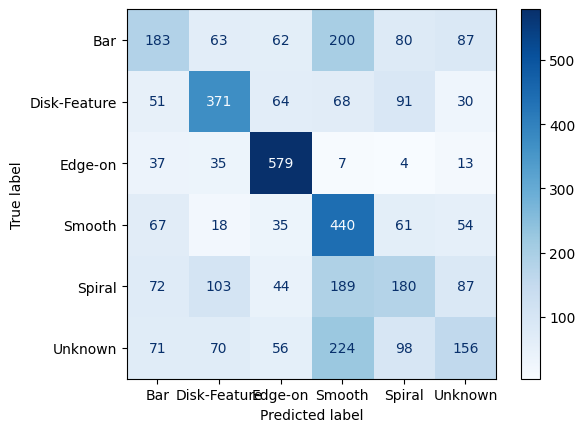

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.27      0.32       675
           1       0.56      0.55      0.56       675
           2       0.69      0.86      0.76       675
           3       0.39      0.65      0.49       675
           4       0.35      0.27      0.30       675
           5       0.37      0.23      0.28       675

    accuracy                           0.47      4050
   macro avg       0.46      0.47      0.45      4050
weighted avg       0.46      0.47      0.45      4050



In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def plot_confusion_matrix(model, test_loader, class_to_idx, device):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    classes = list(class_to_idx.keys())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    cr = classification_report(all_labels, all_preds)

    # Plot confusion matrix
    disp.plot(cmap=plt.cm.Blues)
    plt.show()
    print("Classification Report:\n", cr)

# Plot confusion matrix
plot_confusion_matrix(pretrained_vit_model, test_loader, class_to_idx_test, device)


In [16]:
import random
import matplotlib.pyplot as plt
from collections import defaultdict

def predict_on_random_images(model, test_loader, class_to_idx, device, num_images, rows, cols, figsize):
    model.eval()
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    # Group images by class
    class_images = defaultdict(list)

    with torch.no_grad():
        for images, labels in test_loader:
            for j in range(len(images)):
                class_name = idx_to_class[labels[j].item()]
                class_images[class_name].append((images[j], labels[j]))

    # Ensure we select images randomly from all available classes
    images_to_show = []
    true_labels = []
    predicted_labels = []

    for class_name in class_images:
        # Randomly sample images for each class (at most num_images)
        selected_samples = random.sample(class_images[class_name], min(len(class_images[class_name]), num_images // len(class_images)))

        for image, label in selected_samples:
            images_to_show.append(image)
            true_labels.append(class_name)

            # Move the data to the GPU (if available) and add batch dimension
            image = image.unsqueeze(0).to(device)

            # Get model predictions
            outputs = model(image)  # Pass the single image with batch dimension
            _, preds = torch.max(outputs, 1)

            # Collect predicted labels
            predicted_labels.append(idx_to_class[preds.item()])

            if len(images_to_show) >= num_images:
                break

    # Set up the figure for plotting
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    # Plot the images with true and predicted labels
    for i, ax in enumerate(axes):
        if i < len(images_to_show):
            image = images_to_show[i].permute(1, 2, 0).cpu().numpy()  # Convert to numpy for plotting
            image = (image - image.min()) / (image.max() - image.min())  # Normalize to 0-1
            ax.imshow(image)
            ax.set_title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
            ax.axis("off")
        else:
            ax.axis("off")  # Hide any extra subplots

    plt.tight_layout()
    plt.show()


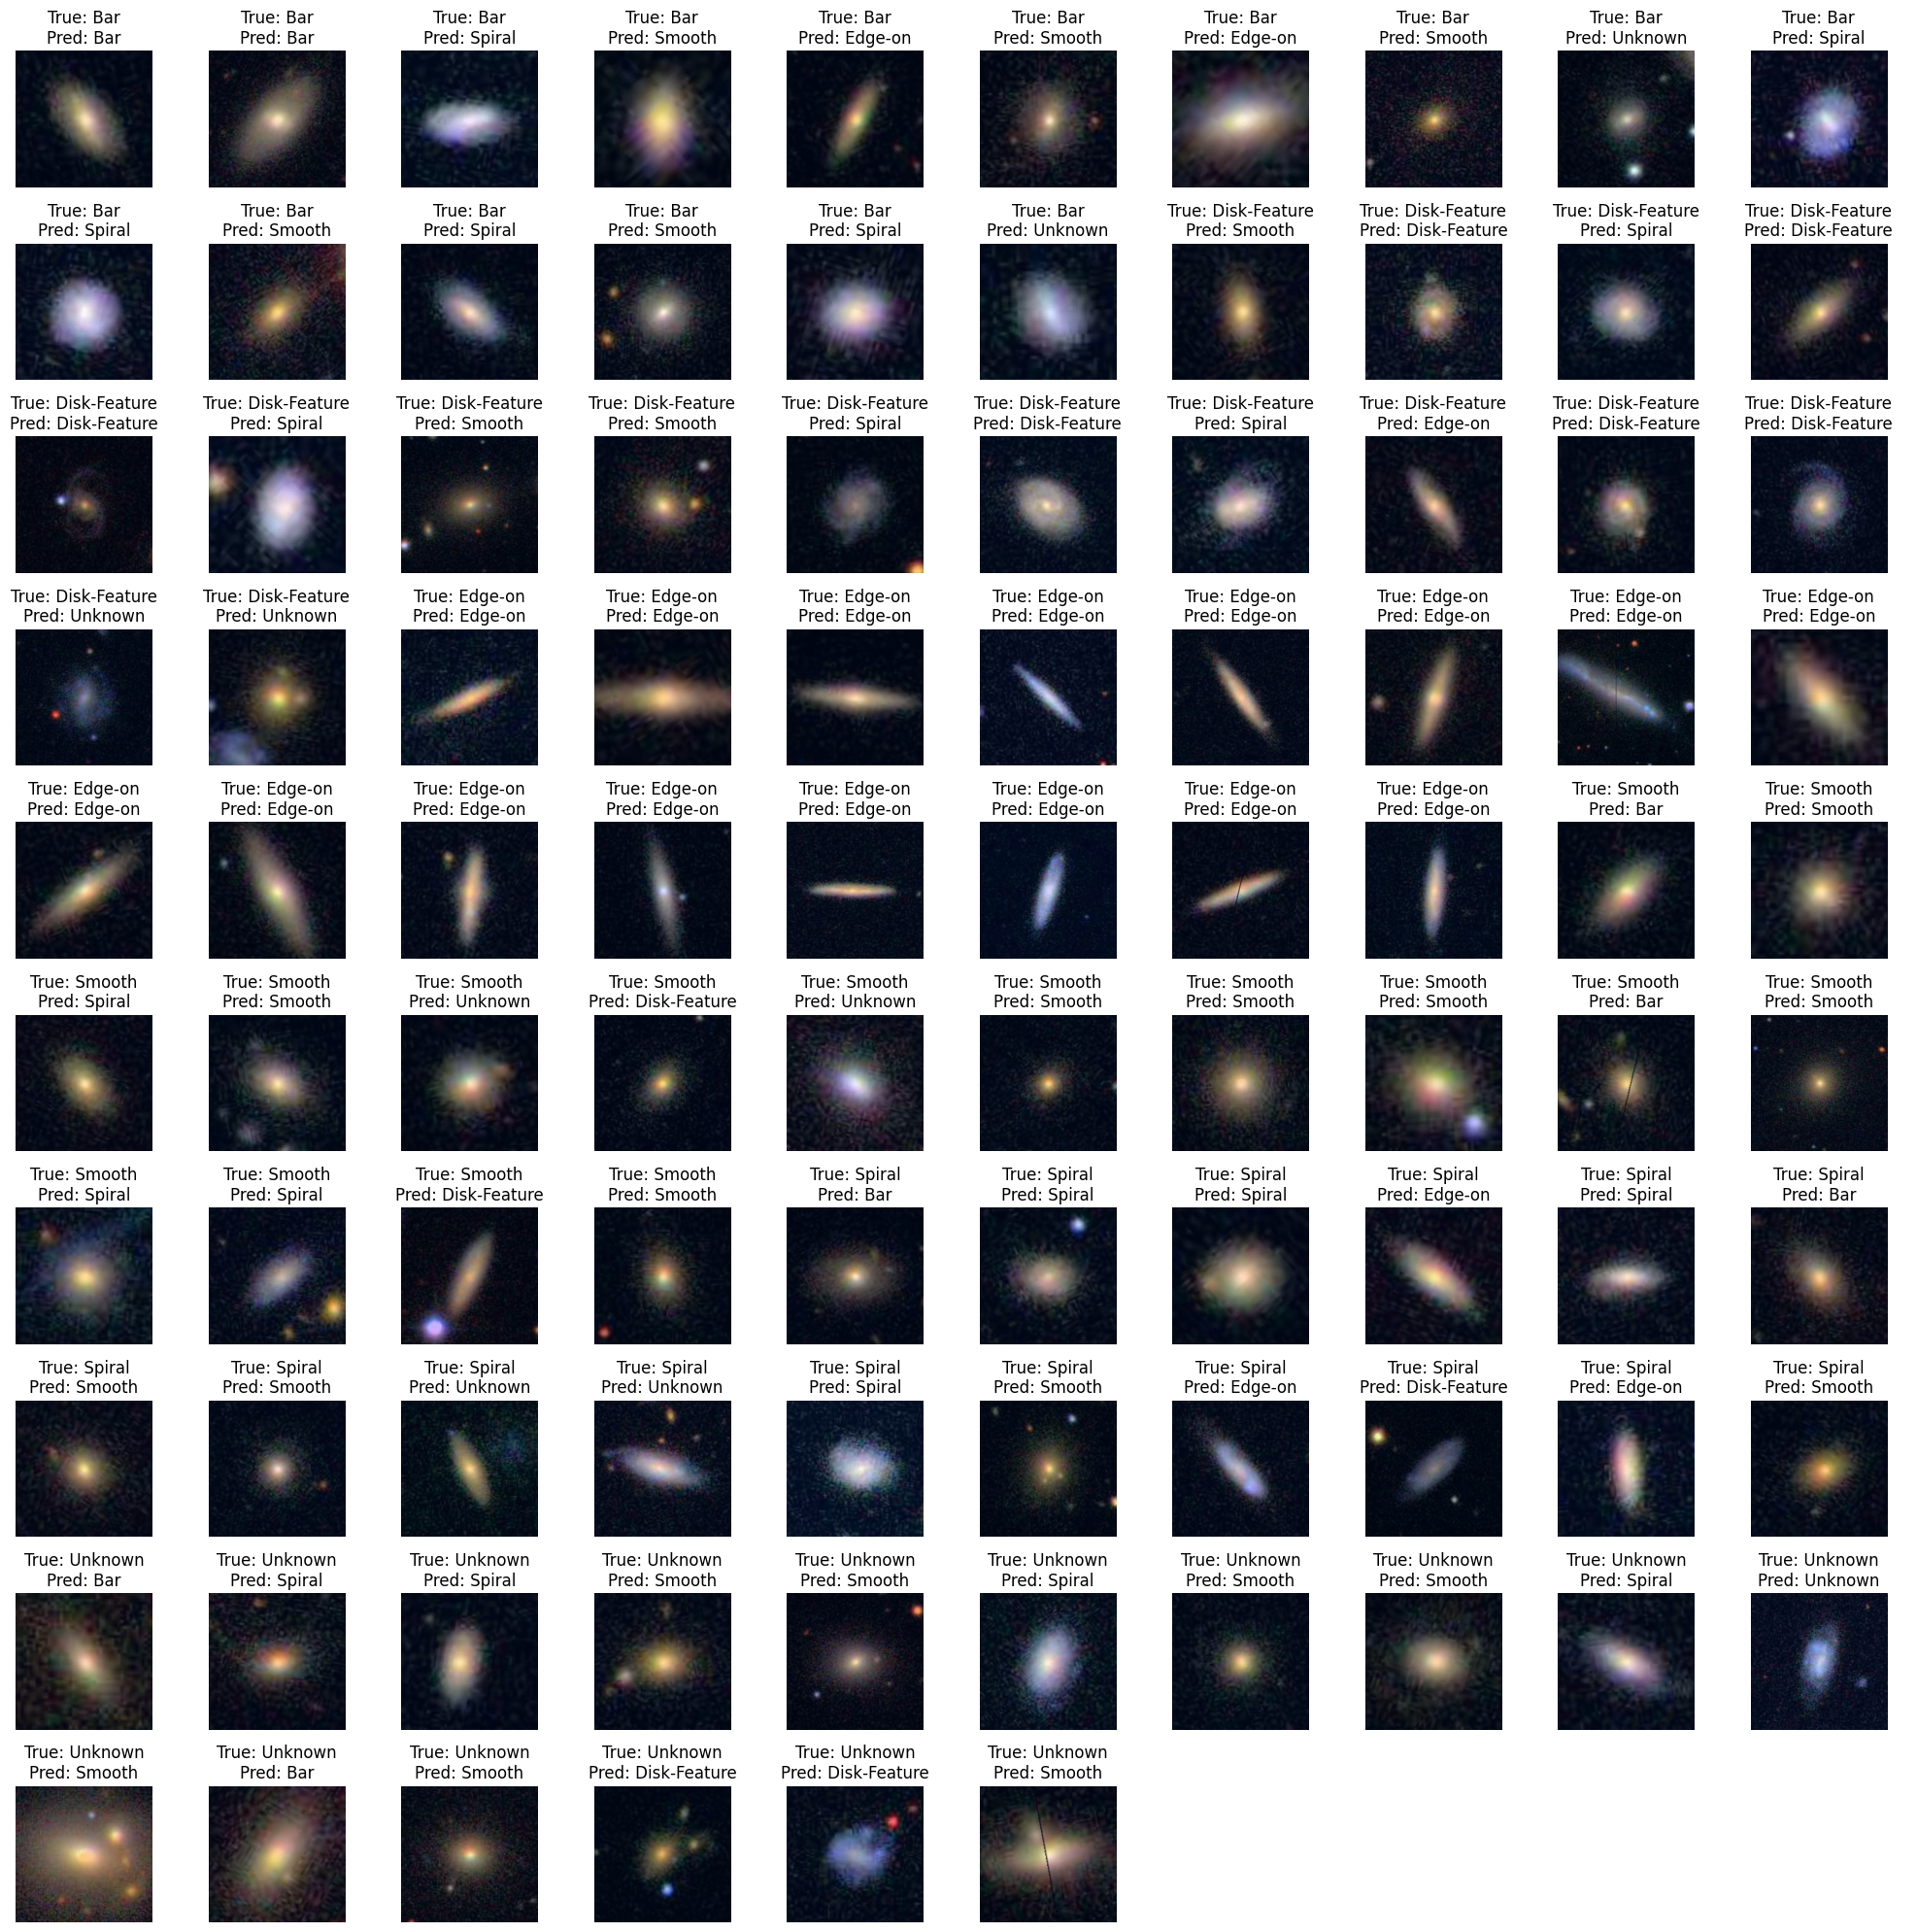

In [17]:
num_images = 100
cols=10
rows=10
figsize=(20, 20)
# Example Usage
predict_on_random_images(pretrained_vit_model, test_loader, class_to_idx_test, device, num_images, rows, cols, figsize)


In [19]:

def count_true_predictions(model, test_loader, class_to_idx, device):
    model.eval()
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    true_predictions_per_class = defaultdict(int)
    total_images_per_class = defaultdict(int)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(images)):
                true_class = idx_to_class[labels[i].item()]
                predicted_class = idx_to_class[preds[i].item()]
                total_images_per_class[true_class] += 1
                if true_class == predicted_class:
                    true_predictions_per_class[true_class] += 1

    return true_predictions_per_class, total_images_per_class
# Example usage:
true_predictions, total_images = count_true_predictions(pretrained_vit_model, test_loader, class_to_idx_test, device)
print(true_predictions)
total_images

defaultdict(<class 'int'>, {'Bar': 183, 'Disk-Feature': 371, 'Edge-on': 579, 'Smooth': 440, 'Spiral': 180, 'Unknown': 156})


defaultdict(int,
            {'Bar': 675,
             'Disk-Feature': 675,
             'Edge-on': 675,
             'Smooth': 675,
             'Spiral': 675,
             'Unknown': 675})